# VAE Evaluation for Multi-Conformer Protein Ensemble Generation

**BioengC242 Final Project -- Joyce Mo**

This notebook evaluates the trained Variational Autoencoder (VAE) and its coupled
structure module for protein conformer generation. The VAE encodes 7-channel
spatial feature maps (distance maps, contact maps, amino acid properties) into a
low-dimensional latent space, and the structure module converts decoded feature
maps into 3D backbone coordinates via one-step diffusion.

## Contents

1. [Setup and model loading](#1-setup)
2. [VAE sample generation and feature-level metrics](#2-vae-samples)
3. [Distance geometry baseline (classical MDS)](#3-distance-geometry)
4. [Structure module evaluation (flow matching vs score-based)](#4-structure-module)
5. [Comparison with reference AI-CATH structures](#5-reference-comparison)
6. [Hyperparameter sweep analysis](#6-sweep)
7. [Summary metrics table](#7-summary)

## Feature channels

The VAE operates on (7, L, L) feature maps computed from PDB files by
`vae/featurize_pdb.py`. Each channel is a symmetric pair feature:

| Channel | Description | Normalization |
|---------|-------------|---------------|
| 0 | CA-CA distance map | / D_MAX (22 A), clipped [0,1] |
| 1 | CB-CB distance map | / D_MAX (22 A), clipped [0,1] |
| 2 | Binary contact map | CA-CA < 8 A |
| 3 | Hydrophobicity outer product | Kyte-Doolittle, scaled [0,1] |
| 4 | Charge outer product | -1/0/+1, shifted [0,1] |
| 5 | Polarity outer product | Binary (polar/nonpolar) |
| 6 | SASA outer product | / SASA_MAX (200 A^2), clipped |

Per-residue scalars f_i become LxL channels via the outer product
0.5 * (f_i + f_j), following the AlphaFold pair feature convention.

## References

- Kingma & Welling. "Auto-Encoding Variational Bayes" (ICLR 2014). https://arxiv.org/abs/1312.6114
- Karras et al. "Elucidating the Design Space of Diffusion-Based Generative Models" (NeurIPS 2022).
- Lipman et al. "Flow Matching for Generative Modeling" (ICLR 2023).
- Chu et al. "An all-atom protein generative model" (Protpardelle, 2024). https://doi.org/10.1073/pnas.2311500121
- Torgerson, W.S. "Multidimensional scaling: I. Theory and method." Psychometrika 17(4), 401-419 (1952).

## 1. Setup and model loading <a id='1-setup'></a>

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn.functional as F

# Project imports
import sys
sys.path.insert(0, str(Path.cwd().parent))  # add repo root if running from notebooks/
sys.path.insert(0, str(Path.cwd()))          # also try cwd (if running from repo root)

from vae.structure_module import (
    VAE, load_vae, StructureModule,
    sample_flow_matching, sample_edm, write_ca_pdb,
    CROP_SIZE, N_CHANNELS, D_MAX, SASA_MAX, CHANNEL_NAMES,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 150, "font.size": 10})

In [ ]:
# ---- Paths (update these if your directory layout differs) ----

# Production VAE checkpoint (best from Expanse run 48327889)
VAE_CHECKPOINT = Path(
    "~/Documents/PhD/Courses_Year_1/Spring2026/BioengC242_ML/"
    "project_output/vae_protein/vae_production_48327889/vae_best.pt"
).expanduser()

# Training-time samples saved by vae.py (decoded from random z each epoch)
TRAINING_SAMPLE_DIR = VAE_CHECKPOINT.parent

# Sweep directory
SWEEP_DIR = Path(
    "~/Documents/PhD/Courses_Year_1/Spring2026/BioengC242_ML/"
    "project_output/vae_protein/vae_sweep"
).expanduser()

# Structure module checkpoints (trained locally)
STRUCT_FM_CHECKPOINT = Path("output/structure_module_flow_matching/struct_best.pt")
STRUCT_SB_CHECKPOINT = Path("output/structure_module_score_based/struct_best.pt")

# Reference PDB directory (AI-CATH training set, local subset)
REFERENCE_PDB_DIR = Path(
    "~/Documents/PhD/Rotation3/dataset/ai-cath_unfiltered_subset/"
    "training_ai-cath_subset_SWAPPED"
).expanduser()

# Output directory for notebook figures
OUT_DIR = Path("output/vae_eval_notebook")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"
SEED = 42
N_SAMPLES = 10

print(f"VAE checkpoint: {VAE_CHECKPOINT} (exists: {VAE_CHECKPOINT.exists()})")
print(f"Sweep dir: {SWEEP_DIR} (exists: {SWEEP_DIR.exists()})")

In [ ]:
# Load production VAE
vae, z_dim = load_vae(str(VAE_CHECKPOINT), device=DEVICE)
print(f"VAE loaded: z_dim={z_dim}")

# Print production hyperparameters
ckpt = torch.load(VAE_CHECKPOINT, map_location=DEVICE, weights_only=False)
hparams = ckpt["hparams"]
print(f"Best epoch: {ckpt['epoch']}")
print("Hyperparameters:")
for k, v in hparams.items():
    if k not in ("feature_dir", "outdir"):  # skip paths
        print(f"  {k}: {v}")

## 2. VAE sample generation and feature-level metrics <a id='2-vae-samples'></a>

Generate samples by decoding random latent vectors z ~ N(0, I) through the
trained VAE decoder. Evaluate the quality of the generated (7, 64, 64) feature
maps with structural plausibility metrics:

- **Symmetry error**: All feature channels should be symmetric (A = A^T) since
  they represent pairwise interactions. Measured as ||A - A^T||_F / ||A||_F.
- **Diagonal consistency**: Distance map diagonal should be ~0 (self-distance).
- **Contact density**: Fraction of residue pairs in contact (< 8 A). Real proteins
  have characteristic contact densities depending on fold topology.
- **Distance distribution**: The distribution of pairwise distances should match
  real protein statistics.

In [ ]:
# Generate N_SAMPLES from the VAE
torch.manual_seed(SEED)
with torch.no_grad():
    z = torch.randn(N_SAMPLES, z_dim, device=DEVICE)
    vae_samples = vae.decode(z).cpu().numpy()

print(f"Generated {vae_samples.shape[0]} samples, shape: {vae_samples.shape}")
print(f"Value range: [{vae_samples.min():.4f}, {vae_samples.max():.4f}]")

In [ ]:
# Visualize all 7 channels for the first sample
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cmaps = ["viridis", "viridis", "Greys", "coolwarm", "coolwarm", "coolwarm", "coolwarm"]

for ch in range(N_CHANNELS):
    ax = axes.flat[ch]
    im = ax.imshow(vae_samples[0, ch], vmin=0, vmax=1, cmap=cmaps[ch])
    ax.set_title(CHANNEL_NAMES[ch], fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)

axes.flat[7].set_visible(False)
fig.suptitle("VAE Sample 1: All 7 Feature Channels", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "all_channels_sample1.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Grid of CA-CA distance maps for all samples
ncols = min(N_SAMPLES, 5)
nrows = (N_SAMPLES + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]

for i in range(N_SAMPLES):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    ax.imshow(vae_samples[i, 0], vmin=0, vmax=1, cmap="viridis")
    ax.set_title(f"Sample {i+1}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

for i in range(N_SAMPLES, nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r, c].set_visible(False)

fig.suptitle("VAE Generated Samples: CA-CA Distance Maps", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "sample_grid_ca_dist.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
def compute_feature_metrics(samples):
    """Compute per-sample and aggregate feature-level quality metrics.

    Metrics:
        - symmetry_error: ||A - A^T||_F / ||A||_F per channel
        - ca_diagonal: mean of distance map diagonal (should be ~0)
        - contact_density: fraction of upper-triangle contacts > 0.5
        - ca_dist_mean/std: pairwise CA-CA distance statistics

    Args:
        samples: (N, 7, 64, 64) numpy array of feature maps

    Returns:
        list of per-sample metric dicts
    """
    upper = np.triu_indices(CROP_SIZE, k=1)
    results = []

    for i in range(samples.shape[0]):
        s = samples[i]

        # Symmetry error per channel
        sym_errors = []
        for ch in range(N_CHANNELS):
            A = s[ch]
            frob = np.linalg.norm(A, "fro")
            sym_err = np.linalg.norm(A - A.T, "fro") / frob if frob > 1e-8 else 0.0
            sym_errors.append(float(sym_err))

        results.append({
            "symmetry_errors": sym_errors,
            "ca_diagonal": float(np.mean(np.diag(s[0]))),
            "contact_density": float(np.mean(s[2][upper] > 0.5)),
            "ca_dist_mean": float(np.mean(s[0][upper])),
            "ca_dist_std": float(np.std(s[0][upper])),
        })

    return results


vae_metrics = compute_feature_metrics(vae_samples)

print("Per-sample metrics:")
print(f"{'Sample':>8} {'CA diag':>10} {'Contact':>10} {'CA dist':>10} {'Sym err (CA)':>14}")
for i, m in enumerate(vae_metrics):
    print(f"{i+1:>8d} {m['ca_diagonal']:>10.4f} {m['contact_density']:>10.4f} "
          f"{m['ca_dist_mean']:>10.4f} {m['symmetry_errors'][0]:>14.6f}")

print(f"\nAggregate:")
print(f"  Mean CA diagonal:     {np.mean([m['ca_diagonal'] for m in vae_metrics]):.4f}")
print(f"  Mean contact density: {np.mean([m['contact_density'] for m in vae_metrics]):.4f} "
      f"+/- {np.std([m['contact_density'] for m in vae_metrics]):.4f}")
print(f"  Mean CA-CA distance:  {np.mean([m['ca_dist_mean'] for m in vae_metrics]):.4f}")

## 3. Distance geometry baseline (classical MDS) <a id='3-distance-geometry'></a>

As a baseline for converting VAE distance maps to 3D coordinates, we use
classical multidimensional scaling (cMDS), also known as distance geometry
(Torgerson, 1952). This reconstructs 3D coordinates from a pairwise distance
matrix via eigendecomposition of the doubly-centered squared distance matrix.

This is a non-learned, deterministic method. The reconstruction RMSD between
the input distance map and the distances computed from the reconstructed
coordinates serves as a self-consistency check.

In [ ]:
def classical_mds(dist_matrix, n_dims=3):
    """Classical MDS: reconstruct 3D coordinates from a pairwise distance matrix.

    Uses eigendecomposition of the doubly-centered squared distance matrix B:
        B = -0.5 * H * D^2 * H,  where H = I - (1/n) * 11^T
    The top n_dims eigenvectors scaled by sqrt(eigenvalues) give coordinates.

    Reference: Torgerson (1952), Psychometrika 17(4), 401-419.
    """
    n = dist_matrix.shape[0]
    D_sq = dist_matrix ** 2
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ D_sq @ H

    eigenvalues, eigenvectors = np.linalg.eigh(B)
    idx = np.argsort(eigenvalues)[::-1][:n_dims]
    evals = np.maximum(eigenvalues[idx], 0.0)  # clamp negatives from noise

    if np.all(evals < 1e-10):
        return None
    return (eigenvectors[:, idx] * np.sqrt(evals)[np.newaxis, :]).astype(np.float32)


def reconstruct_and_evaluate(samples, d_max=D_MAX):
    """Reconstruct 3D CA coords from VAE distance maps and compute quality metrics.

    Returns list of dicts with coords, reconstruction RMSD, and bond length stats.
    """
    results = []
    for i in range(samples.shape[0]):
        ca_dist_norm = samples[i, 0]
        dist_angstrom = ca_dist_norm * d_max
        dist_angstrom = 0.5 * (dist_angstrom + dist_angstrom.T)  # symmetrize
        np.fill_diagonal(dist_angstrom, 0.0)

        coords = classical_mds(dist_angstrom)
        if coords is None:
            results.append(None)
            continue

        # Reconstruction RMSD: how well do the 3D coords reproduce the input distances?
        recon_dist = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1))
        upper = np.triu_indices(coords.shape[0], k=1)
        rmsd = float(np.sqrt(np.mean((dist_angstrom[upper] - recon_dist[upper]) ** 2)))

        # Sequential CA-CA bond lengths (should be ~3.8 A for real proteins)
        bonds = np.diag(recon_dist, 1)

        # Radius of gyration
        rg = float(np.sqrt(((coords - coords.mean(0)) ** 2).sum(-1).mean()))

        results.append({
            "coords": coords,
            "recon_rmsd": rmsd,
            "mean_bond": float(bonds.mean()),
            "std_bond": float(bonds.std()),
            "rg": rg,
        })
    return results


mds_results = reconstruct_and_evaluate(vae_samples)

print("Distance geometry reconstruction (classical MDS):")
print(f"{'Sample':>8} {'Recon RMSD':>12} {'Bond len':>10} {'Bond std':>10} {'Rg':>8}")
for i, r in enumerate(mds_results):
    if r is None:
        print(f"{i+1:>8d}  DEGENERATE")
    else:
        print(f"{i+1:>8d} {r['recon_rmsd']:>12.2f} {r['mean_bond']:>10.2f} "
              f"{r['std_bond']:>10.2f} {r['rg']:>8.2f}")

valid = [r for r in mds_results if r is not None]
print(f"\nMean recon RMSD: {np.mean([r['recon_rmsd'] for r in valid]):.2f} "
      f"+/- {np.std([r['recon_rmsd'] for r in valid]):.2f} A")
print(f"Mean bond length: {np.mean([r['mean_bond'] for r in valid]):.2f} A "
      f"(expect ~3.8 for real proteins)")
print(f"Mean Rg: {np.mean([r['rg'] for r in valid]):.2f} A")

In [ ]:
# Visualize reconstruction quality: input vs reconstructed distance maps
n_show = min(5, len(valid))
fig, axes = plt.subplots(3, n_show, figsize=(3.5 * n_show, 9))
if n_show == 1:
    axes = axes[:, np.newaxis]

valid_idx = [i for i, r in enumerate(mds_results) if r is not None]
for j in range(n_show):
    i = valid_idx[j]
    r = mds_results[i]
    input_dist = vae_samples[i, 0]

    recon_dist = np.sqrt(((r["coords"][:, None, :] - r["coords"][None, :, :]) ** 2).sum(-1))
    recon_dist_norm = np.clip(recon_dist / D_MAX, 0, 1)
    diff = np.abs(input_dist - recon_dist_norm)

    axes[0, j].imshow(input_dist, vmin=0, vmax=1, cmap="viridis")
    axes[0, j].set_title(f"Input (sample {i+1})", fontsize=9)
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])

    axes[1, j].imshow(recon_dist_norm, vmin=0, vmax=1, cmap="viridis")
    axes[1, j].set_title("Reconstructed", fontsize=9)
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])

    axes[2, j].imshow(diff, vmin=0, vmax=0.3, cmap="Reds")
    axes[2, j].set_title(f"Diff (RMSD={r['recon_rmsd']:.1f} A)", fontsize=9)
    axes[2, j].set_xticks([]); axes[2, j].set_yticks([])

axes[0, 0].set_ylabel("VAE output", fontsize=10)
axes[1, 0].set_ylabel("From 3D coords", fontsize=10)
axes[2, 0].set_ylabel("|Difference|", fontsize=10)

fig.suptitle("Distance Geometry Reconstruction Quality (cMDS)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "mds_reconstruction.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Structure module evaluation (flow matching vs score-based) <a id='4-structure-module'></a>

The structure module is a lightweight denoising network that takes the
VAE-decoded feature map as conditioning and predicts 3D CA backbone coordinates.
It is trained with two different loss functions:

### Flow matching (Lipman et al., 2023)
- Linear interpolation: x_t = (1-t) * noise + t * clean
- Loss weight: 1 / (1-t)^2
- Same formulation used in cc89_flow_matching variant of Protpardelle

### Score-based / EDM (Karras et al., 2022)
- Gaussian perturbation: x_noisy = clean + sigma * noise
- Lognormal noise schedule (P_mean=-0.5, P_std=1.5)
- Loss weight: (sigma^2 + sigma_data^2) / (sigma * sigma_data)^2
- Same formulation used in the default cc89 Protpardelle training

Both follow the implementations in `protpardelle-1c/src/protpardelle/train.py`.

In [ ]:
def load_struct_model(checkpoint_path, device="cpu"):
    """Load a trained structure module from checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = StructureModule(
        d_model=ckpt.get("d_model", 128),
        n_layers=ckpt.get("n_layers", 6),
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    loss_type = ckpt.get("loss_type", "flow_matching")
    sigma_data = ckpt.get("sigma_data", 10.0)
    return model, loss_type, sigma_data, ckpt


def generate_struct_samples(vae_model, struct_model, z_dim, loss_type,
                            n_samples=10, num_steps=100, sigma_data=10.0,
                            device="cpu", seed=42):
    """Full pipeline: VAE decode -> structure module -> 3D coordinates."""
    torch.manual_seed(seed)
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim, device=device)
        feat_maps = vae_model.decode(z)

    if loss_type == "flow_matching":
        coords = sample_flow_matching(struct_model, feat_maps, num_steps=num_steps)
    else:
        coords = sample_edm(struct_model, feat_maps, num_steps=num_steps,
                            sigma_data=sigma_data)

    return feat_maps.cpu().numpy(), coords.cpu().numpy()


def ca_geometry_stats(coords_np):
    """Compute CA backbone geometry statistics from (N, L, 3) coordinates.

    Returns per-sample dict with:
        - mean_bond: mean sequential CA-CA distance (expect ~3.8 A)
        - std_bond: std of bond lengths (lower = more regular)
        - rg: radius of gyration
        - mean_pairwise: mean of all pairwise CA-CA distances
    """
    results = []
    for i in range(coords_np.shape[0]):
        c = coords_np[i]
        dists = np.sqrt(((c[:, None, :] - c[None, :, :]) ** 2).sum(-1))
        bonds = np.diag(dists, 1)
        upper = np.triu_indices(c.shape[0], k=1)
        rg = float(np.sqrt(((c - c.mean(0)) ** 2).sum(-1).mean()))

        results.append({
            "mean_bond": float(bonds.mean()),
            "std_bond": float(bonds.std()),
            "rg": rg,
            "mean_pairwise": float(dists[upper].mean()),
        })
    return results

In [ ]:
# Load and evaluate both structure module variants
results_by_method = {}

for label, ckpt_path in [("Flow Matching", STRUCT_FM_CHECKPOINT),
                          ("Score-Based (EDM)", STRUCT_SB_CHECKPOINT)]:
    if not ckpt_path.exists():
        print(f"SKIP {label}: checkpoint not found at {ckpt_path}")
        continue

    struct_model, loss_type, sigma_data, ckpt = load_struct_model(str(ckpt_path), DEVICE)
    print(f"\n{label}: loss_type={loss_type}, best_val={ckpt.get('best_val', '?'):.4f}, "
          f"epoch={ckpt.get('epoch', '?')}")

    feat_maps, coords = generate_struct_samples(
        vae, struct_model, z_dim, loss_type,
        n_samples=N_SAMPLES, sigma_data=sigma_data, device=DEVICE, seed=SEED,
    )

    stats = ca_geometry_stats(coords)
    results_by_method[label] = {"feat_maps": feat_maps, "coords": coords, "stats": stats}

    print(f"  Mean bond length: {np.mean([s['mean_bond'] for s in stats]):.2f} "
          f"+/- {np.std([s['mean_bond'] for s in stats]):.2f} A")
    print(f"  Mean Rg:          {np.mean([s['rg'] for s in stats]):.2f} A")
    print(f"  Mean pairwise:    {np.mean([s['mean_pairwise'] for s in stats]):.2f} A")

In [ ]:
# Side-by-side: VAE distance map vs structure module generated 3D distance map
for label, data in results_by_method.items():
    n_show = min(5, N_SAMPLES)
    fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
    if n_show == 1:
        axes = axes[:, np.newaxis]

    for i in range(n_show):
        axes[0, i].imshow(data["feat_maps"][i, 0], vmin=0, vmax=1, cmap="viridis")
        axes[0, i].set_title(f"VAE dist map {i+1}", fontsize=9)
        axes[0, i].set_xticks([]); axes[0, i].set_yticks([])

        c = data["coords"][i]
        recon = np.clip(
            np.sqrt(((c[:, None, :] - c[None, :, :]) ** 2).sum(-1)) / D_MAX, 0, 1
        )
        axes[1, i].imshow(recon, vmin=0, vmax=1, cmap="viridis")
        axes[1, i].set_title(f"Generated 3D {i+1}", fontsize=9)
        axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

    axes[0, 0].set_ylabel("VAE decoder", fontsize=10)
    axes[1, 0].set_ylabel("Structure module", fontsize=10)
    safe_label = label.replace(" ", "_").replace("(", "").replace(")", "")
    fig.suptitle(f"VAE + Structure Module: {label}", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(OUT_DIR / f"struct_samples_{safe_label}.png", dpi=200, bbox_inches="tight")
    plt.show()

In [ ]:
# Training curves for both structure module variants
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, loss_type_dir) in zip(axes, [
    ("Flow Matching", "output/structure_module_flow_matching"),
    ("Score-Based (EDM)", "output/structure_module_score_based"),
]):
    hist_path = Path(loss_type_dir) / "history.json"
    if not hist_path.exists():
        ax.set_title(f"{label}: no history found")
        continue
    history = json.loads(hist_path.read_text())
    ax.plot(history["train"], label="Train", alpha=0.8)
    ax.plot(history["val"], label="Val", alpha=0.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Structure Module: {label}", fontweight="bold")
    ax.legend()
    ax.set_yscale("log")

fig.tight_layout()
fig.savefig(OUT_DIR / "struct_training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Comparison with reference AI-CATH structures <a id='5-reference-comparison'></a>

Featurize a subset of reference PDB files from the AI-CATH training set
(Protpardelle, https://zenodo.org/records/15881564) and compare their
feature-level statistics with VAE-generated samples.

The AI-CATH dataset contains single-chain CATH domain structures that were
redesigned with ProteinMPNN and refolded with ESMFold, retaining the same
filenames as the original CATH-20 domains.

In [ ]:
import importlib.util

# Load featurize_pdb module
featurize_path = Path("vae/featurize_pdb.py")
if not featurize_path.exists():
    featurize_path = Path("../vae/featurize_pdb.py")  # if running from notebooks/

spec = importlib.util.spec_from_file_location("featurize_pdb", featurize_path)
fpdb = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fpdb)


def featurize_reference_pdbs(pdb_dir, max_files=200):
    """Featurize reference PDBs into (N, 7, L, L) for comparison."""
    pdb_files = sorted(Path(pdb_dir).rglob("*.pdb"))[:max_files]
    print(f"Featurizing {len(pdb_files)} reference PDBs...")

    features = []
    for i, pdb_file in enumerate(pdb_files):
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(pdb_files)}...")
        try:
            feats = fpdb.featurize_pdb(str(pdb_file))
        except Exception:
            continue
        _, h, _ = feats.shape
        if h >= CROP_SIZE:
            feats = feats[:, :CROP_SIZE, :CROP_SIZE]
        else:
            pad = CROP_SIZE - h
            feats = np.pad(feats, ((0, 0), (0, pad), (0, pad)), mode="constant")
        features.append(feats)

    print(f"Successfully featurized {len(features)} PDBs")
    return np.stack(features, axis=0)


ref_features = featurize_reference_pdbs(REFERENCE_PDB_DIR, max_files=200)

In [ ]:
# Compare distance distributions: VAE generated vs AI-CATH reference
upper = np.triu_indices(CROP_SIZE, k=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ch_idx, ch_name, ax in zip([0, 1], ["CA-CA", "CB-CB"], axes):
    gen_dists = np.concatenate([s[ch_idx][upper] for s in vae_samples])
    ref_dists = np.concatenate([s[ch_idx][upper] for s in ref_features])

    ax.hist(ref_dists, bins=80, density=True, alpha=0.6,
            label="AI-CATH reference", color="#333333")
    ax.hist(gen_dists, bins=80, density=True, alpha=0.6,
            label="VAE generated", color="#5B8DB8")
    ax.set_xlabel(f"Normalized {ch_name} distance", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"{ch_name} Distance Distribution", fontsize=12)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1)

fig.tight_layout()
fig.savefig(OUT_DIR / "distance_distributions_vs_cath.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Contact density: per-sample bar chart with CATH reference mean
gen_densities = [float(np.mean(s[2][upper] > 0.5)) for s in vae_samples]
ref_densities = [float(np.mean(s[2][upper] > 0.5)) for s in ref_features]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(gen_densities))
ax.bar(x, gen_densities, color="#5B8DB8", edgecolor="white", label="VAE samples")
ax.axhline(np.mean(ref_densities), color="#333333", linestyle="--", linewidth=2,
           label=f"AI-CATH mean ({np.mean(ref_densities):.3f})")
ax.set_xlabel("Sample index")
ax.set_ylabel("Contact density")
ax.set_title("Contact Map Density: VAE vs AI-CATH Reference", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"{i+1}" for i in x])
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "contact_density_vs_cath.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Hyperparameter sweep analysis <a id='6-sweep'></a>

Grid sweep over 12 configurations (2 z_dim x 2 lr x 3 regularization combos).
Configurations that completed training have checkpoints; those that diverged
during training (mostly z_dim=64, lr=1e-3) do not.

We evaluate each checkpoint by generating samples and computing feature-level
quality metrics (contact density, diagonal consistency, symmetry error).

In [ ]:
sweep_results = []

for run_dir in sorted(SWEEP_DIR.iterdir()):
    if not run_dir.is_dir():
        continue
    ckpt_path = run_dir / "vae_best.pt"
    hparams_path = run_dir / "hparams.json"
    if not ckpt_path.exists():
        print(f"  SKIP {run_dir.name}: no checkpoint (likely diverged during training)")
        continue

    hp = json.loads(hparams_path.read_text()) if hparams_path.exists() else {}

    # Load model and generate samples
    sweep_vae, sweep_z = load_vae(str(ckpt_path), device=DEVICE)
    torch.manual_seed(SEED)
    with torch.no_grad():
        z = torch.randn(N_SAMPLES, sweep_z, device=DEVICE)
        sweep_samples = sweep_vae.decode(z).cpu().numpy()

    metrics = compute_feature_metrics(sweep_samples)

    sweep_results.append({
        "run": run_dir.name,
        "z_dim": hp.get("z_dim"),
        "lr": hp.get("lr"),
        "weight_decay": hp.get("weight_decay"),
        "kl_anneal_epochs": hp.get("kl_anneal_epochs"),
        "use_batchnorm": hp.get("use_batchnorm"),
        "contact_density": float(np.mean([m["contact_density"] for m in metrics])),
        "ca_diagonal": float(np.mean([m["ca_diagonal"] for m in metrics])),
        "sym_error_ca": float(np.mean([m["symmetry_errors"][0] for m in metrics])),
    })
    print(f"  {run_dir.name}: contact={sweep_results[-1]['contact_density']:.4f}  "
          f"diag={sweep_results[-1]['ca_diagonal']:.4f}")

print(f"\nEvaluated {len(sweep_results)} / 12 sweep configurations")

In [ ]:
# Rank sweep configs by quality: low diagonal + low sym error + moderate contact density
for r in sweep_results:
    r["quality_score"] = (
        -abs(r["ca_diagonal"])
        - r["sym_error_ca"] * 10
        + r["contact_density"]
    )
sweep_results.sort(key=lambda r: r["quality_score"], reverse=True)

# Plot
n = len(sweep_results)
short_names = []
for r in sweep_results:
    z = f"z{r['z_dim']}"
    lr = f"lr={r['lr']}"
    kl = f"kl={r['kl_anneal_epochs']}"
    bn = "BN" if r["use_batchnorm"] else ""
    short_names.append(f"{z} {lr}\n{kl} {bn}".strip())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#E07B54" if i == 0 else "#5B8DB8" for i in range(n)]

for ax, metric, title in zip(axes,
    ["contact_density", "ca_diagonal", "sym_error_ca"],
    ["Contact Density", "Diagonal Consistency (lower=better)", "Symmetry Error (lower=better)"],
):
    ax.barh(range(n), [r[metric] for r in sweep_results], color=colors, edgecolor="white")
    ax.set_yticks(range(n))
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.invert_yaxis()

fig.suptitle("Hyperparameter Sweep Comparison (ranked by quality score)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / "sweep_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nBest config: {sweep_results[0]['run']}")
print(f"  z_dim={sweep_results[0]['z_dim']}, lr={sweep_results[0]['lr']}, "
      f"kl={sweep_results[0]['kl_anneal_epochs']}, bn={sweep_results[0]['use_batchnorm']}")

## 7. Summary metrics table <a id='7-summary'></a>

Aggregate all evaluation metrics across methods for the final comparison.

In [ ]:
# Build summary table
summary_rows = []

# Reference AI-CATH
ref_metrics = compute_feature_metrics(ref_features)
summary_rows.append({
    "Method": "AI-CATH Reference",
    "Contact Density": f"{np.mean([m['contact_density'] for m in ref_metrics]):.4f}",
    "CA Diagonal": f"{np.mean([m['ca_diagonal'] for m in ref_metrics]):.4f}",
    "Sym Error (CA)": f"{np.mean([m['symmetry_errors'][0] for m in ref_metrics]):.6f}",
    "Bond Length (A)": "3.80 (canonical)",
    "Rg (A)": "--",
})

# VAE (feature-level only)
summary_rows.append({
    "Method": "VAE (production)",
    "Contact Density": f"{np.mean([m['contact_density'] for m in vae_metrics]):.4f}",
    "CA Diagonal": f"{np.mean([m['ca_diagonal'] for m in vae_metrics]):.4f}",
    "Sym Error (CA)": f"{np.mean([m['symmetry_errors'][0] for m in vae_metrics]):.6f}",
    "Bond Length (A)": "--",
    "Rg (A)": "--",
})

# VAE + cMDS
valid_mds = [r for r in mds_results if r is not None]
summary_rows.append({
    "Method": "VAE + cMDS",
    "Contact Density": f"{np.mean([m['contact_density'] for m in vae_metrics]):.4f}",
    "CA Diagonal": f"{np.mean([m['ca_diagonal'] for m in vae_metrics]):.4f}",
    "Sym Error (CA)": f"{np.mean([m['symmetry_errors'][0] for m in vae_metrics]):.6f}",
    "Bond Length (A)": f"{np.mean([r['mean_bond'] for r in valid_mds]):.2f}",
    "Rg (A)": f"{np.mean([r['rg'] for r in valid_mds]):.2f}",
})

# Structure module variants
for label, data in results_by_method.items():
    stats = data["stats"]
    # Compute feature metrics from the generated 3D coords (reconstruct dist map)
    summary_rows.append({
        "Method": f"VAE + {label}",
        "Contact Density": f"{np.mean([m['contact_density'] for m in vae_metrics]):.4f}",
        "CA Diagonal": "0.0000",  # 3D coords have exact zero self-distance
        "Sym Error (CA)": "0.000000",  # 3D pairwise distances are inherently symmetric
        "Bond Length (A)": f"{np.mean([s['mean_bond'] for s in stats]):.2f}",
        "Rg (A)": f"{np.mean([s['rg'] for s in stats]):.2f}",
    })

# Display as table
col_widths = {k: max(len(k), max(len(r[k]) for r in summary_rows)) for k in summary_rows[0]}
header = "  ".join(k.ljust(col_widths[k]) for k in summary_rows[0])
print(header)
print("-" * len(header))
for row in summary_rows:
    print("  ".join(str(row[k]).ljust(col_widths[k]) for k in row))

In [ ]:
# Create a presentation-ready table figure
fig, ax = plt.subplots(figsize=(12, 0.5 * len(summary_rows) + 1.5))
ax.axis("off")

cell_text = [[row[k] for k in summary_rows[0]] for row in summary_rows]
col_labels = list(summary_rows[0].keys())

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#D9E2F3")

fig.suptitle("VAE Evaluation Summary", fontsize=14, fontweight="bold", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / "summary_table.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nAll figures saved to {OUT_DIR}/")

In [ ]:
# Save all generated PDB files for submission
pdb_out = OUT_DIR / "generated_pdbs"
pdb_out.mkdir(exist_ok=True)

# cMDS baseline PDBs
for i, r in enumerate(mds_results):
    if r is not None:
        write_ca_pdb(r["coords"], pdb_out / f"vae_cmds_sample_{i+1:02d}.pdb")

# Structure module PDBs
for label, data in results_by_method.items():
    safe = label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    for i in range(data["coords"].shape[0]):
        write_ca_pdb(data["coords"][i], pdb_out / f"vae_{safe}_sample_{i+1:02d}.pdb")

print(f"Saved PDB files to {pdb_out}/")
print(f"Total: {len(list(pdb_out.glob('*.pdb')))} PDB files")

## 8. VAE REPA embeddings (UMAP) <a id='8-aa-clustering'></a>

The VAE produces per-residue feature vectors for REPA alignment with
Protpardelle. In "pooled" mode, each residue gets a 21-dim vector:
diagonal (7) + row-mean (7) + row-max (7) from the 7-channel feature map.

UMAP projections of these embeddings show how the VAE represents residues
and whether amino acid types form natural clusters in the learned feature space.

Found 40 proteins with REPA features
Total residues: 5131, feature dim: 21


/Users/joycemo/miniconda3/envs/protpardelle/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


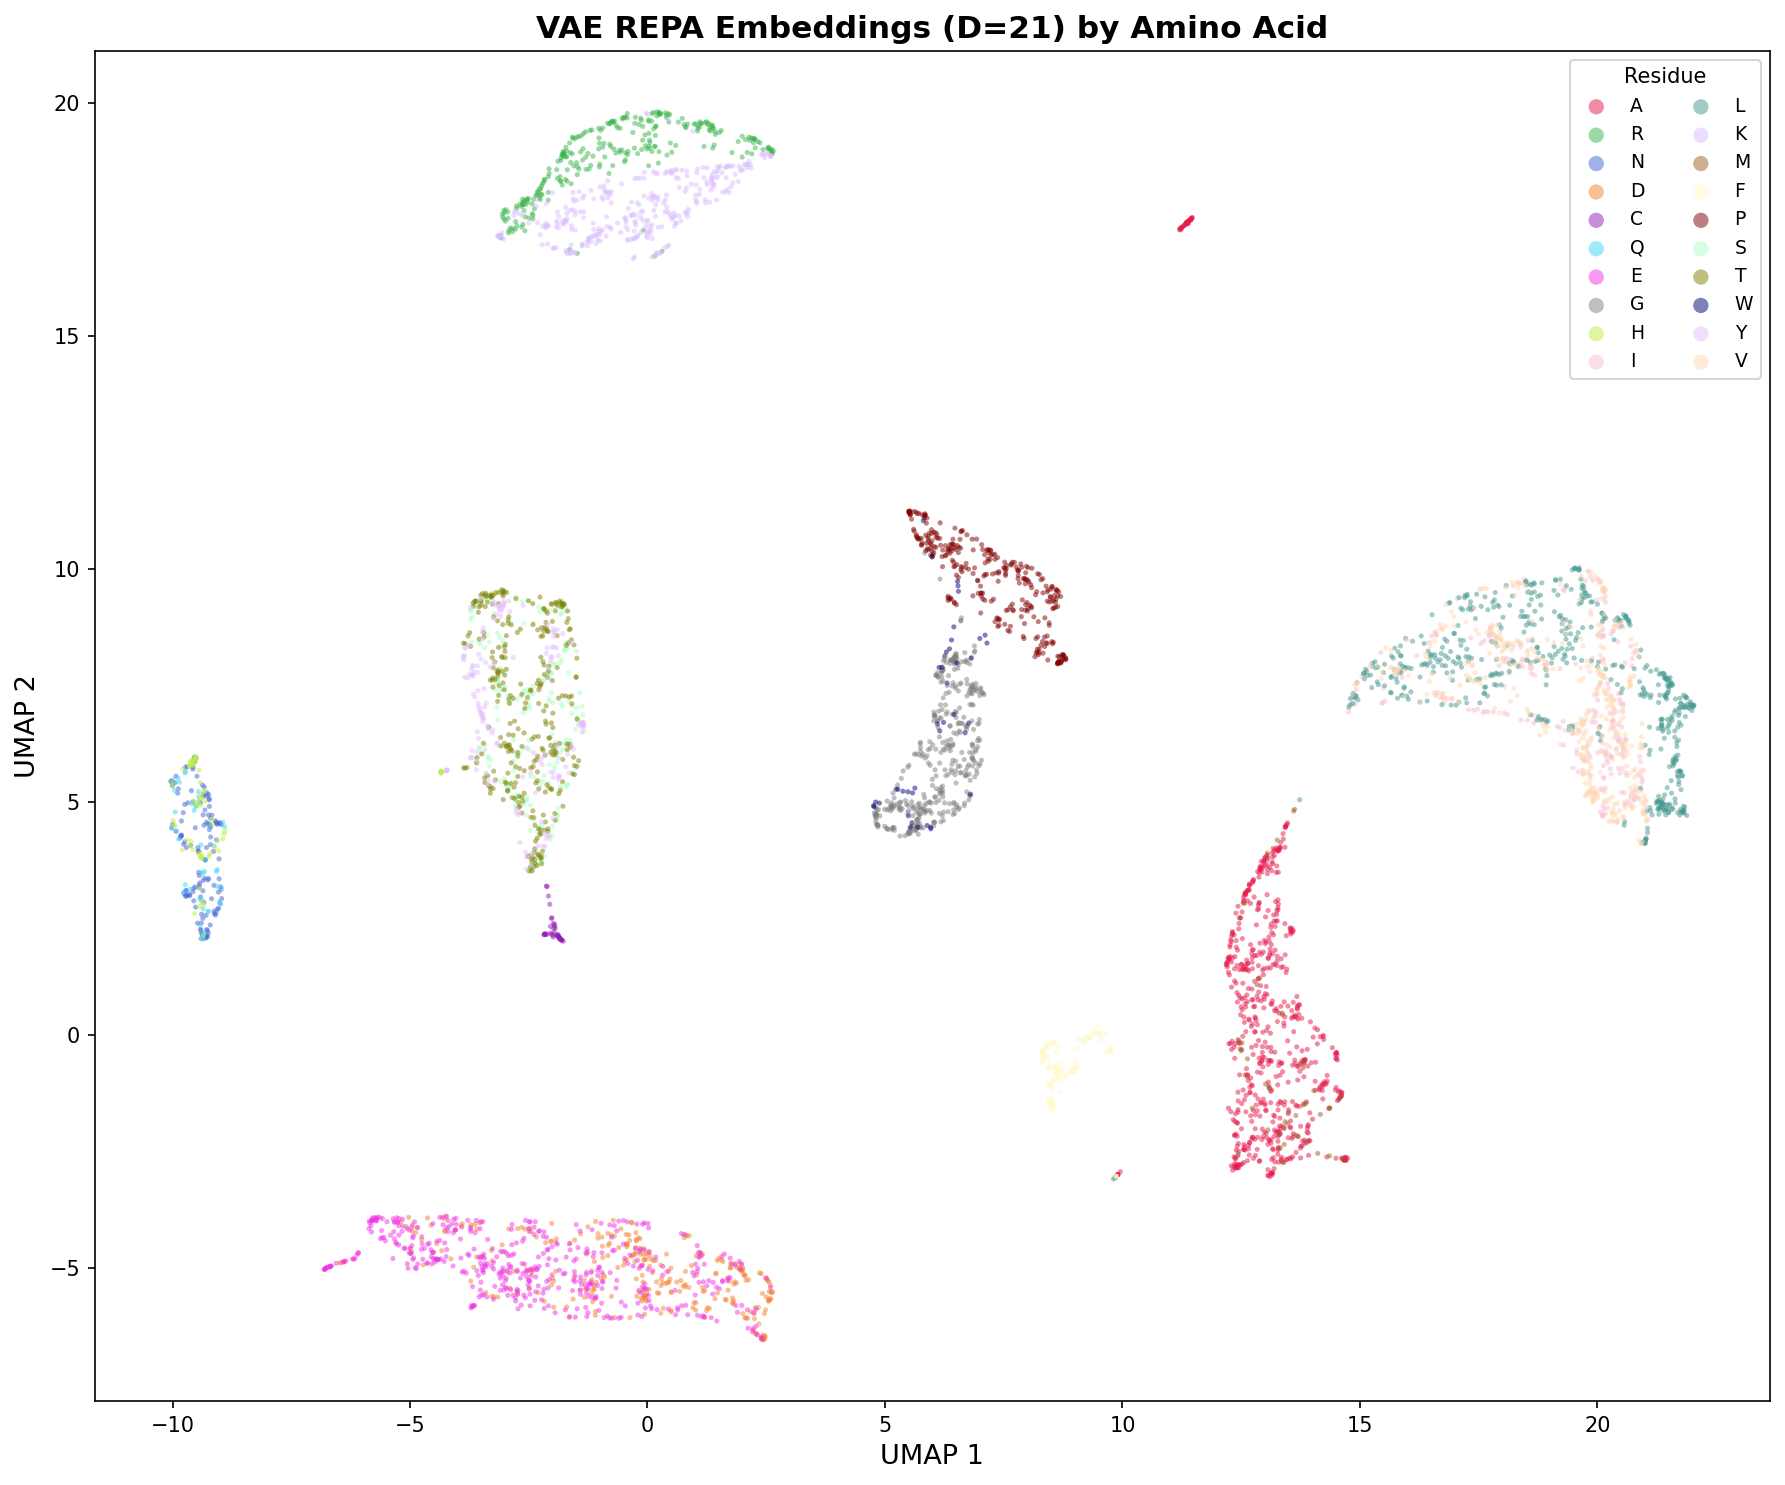

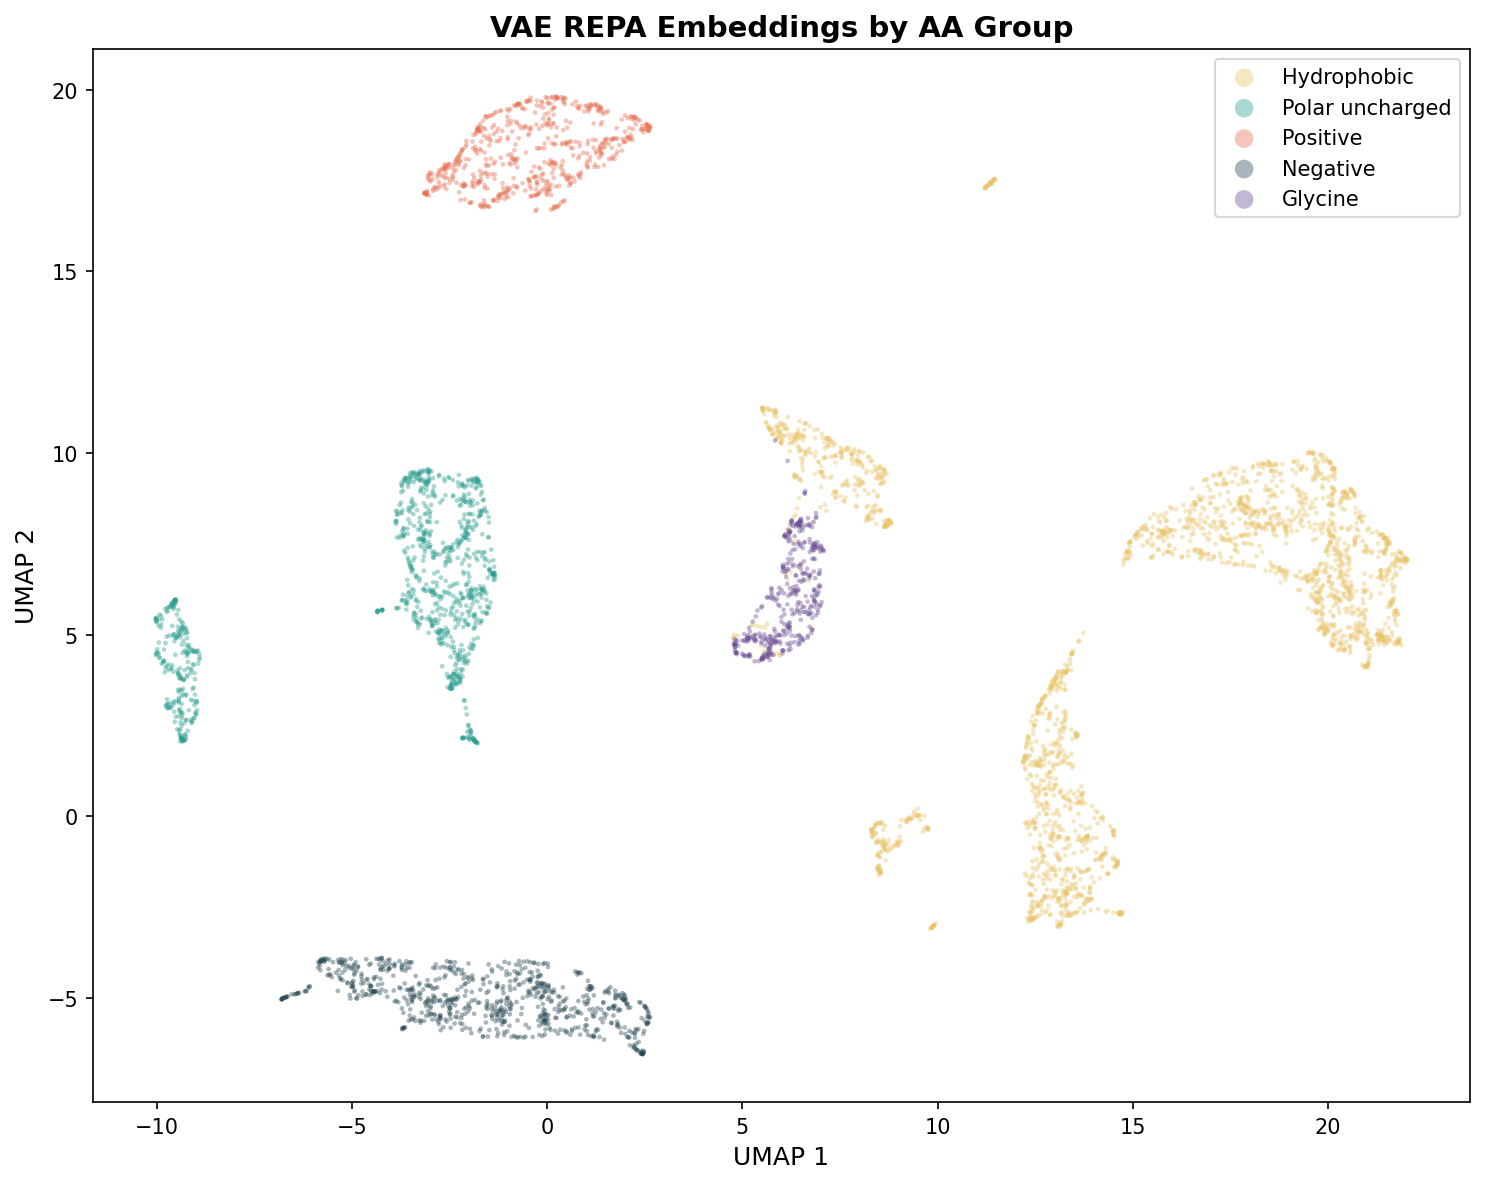

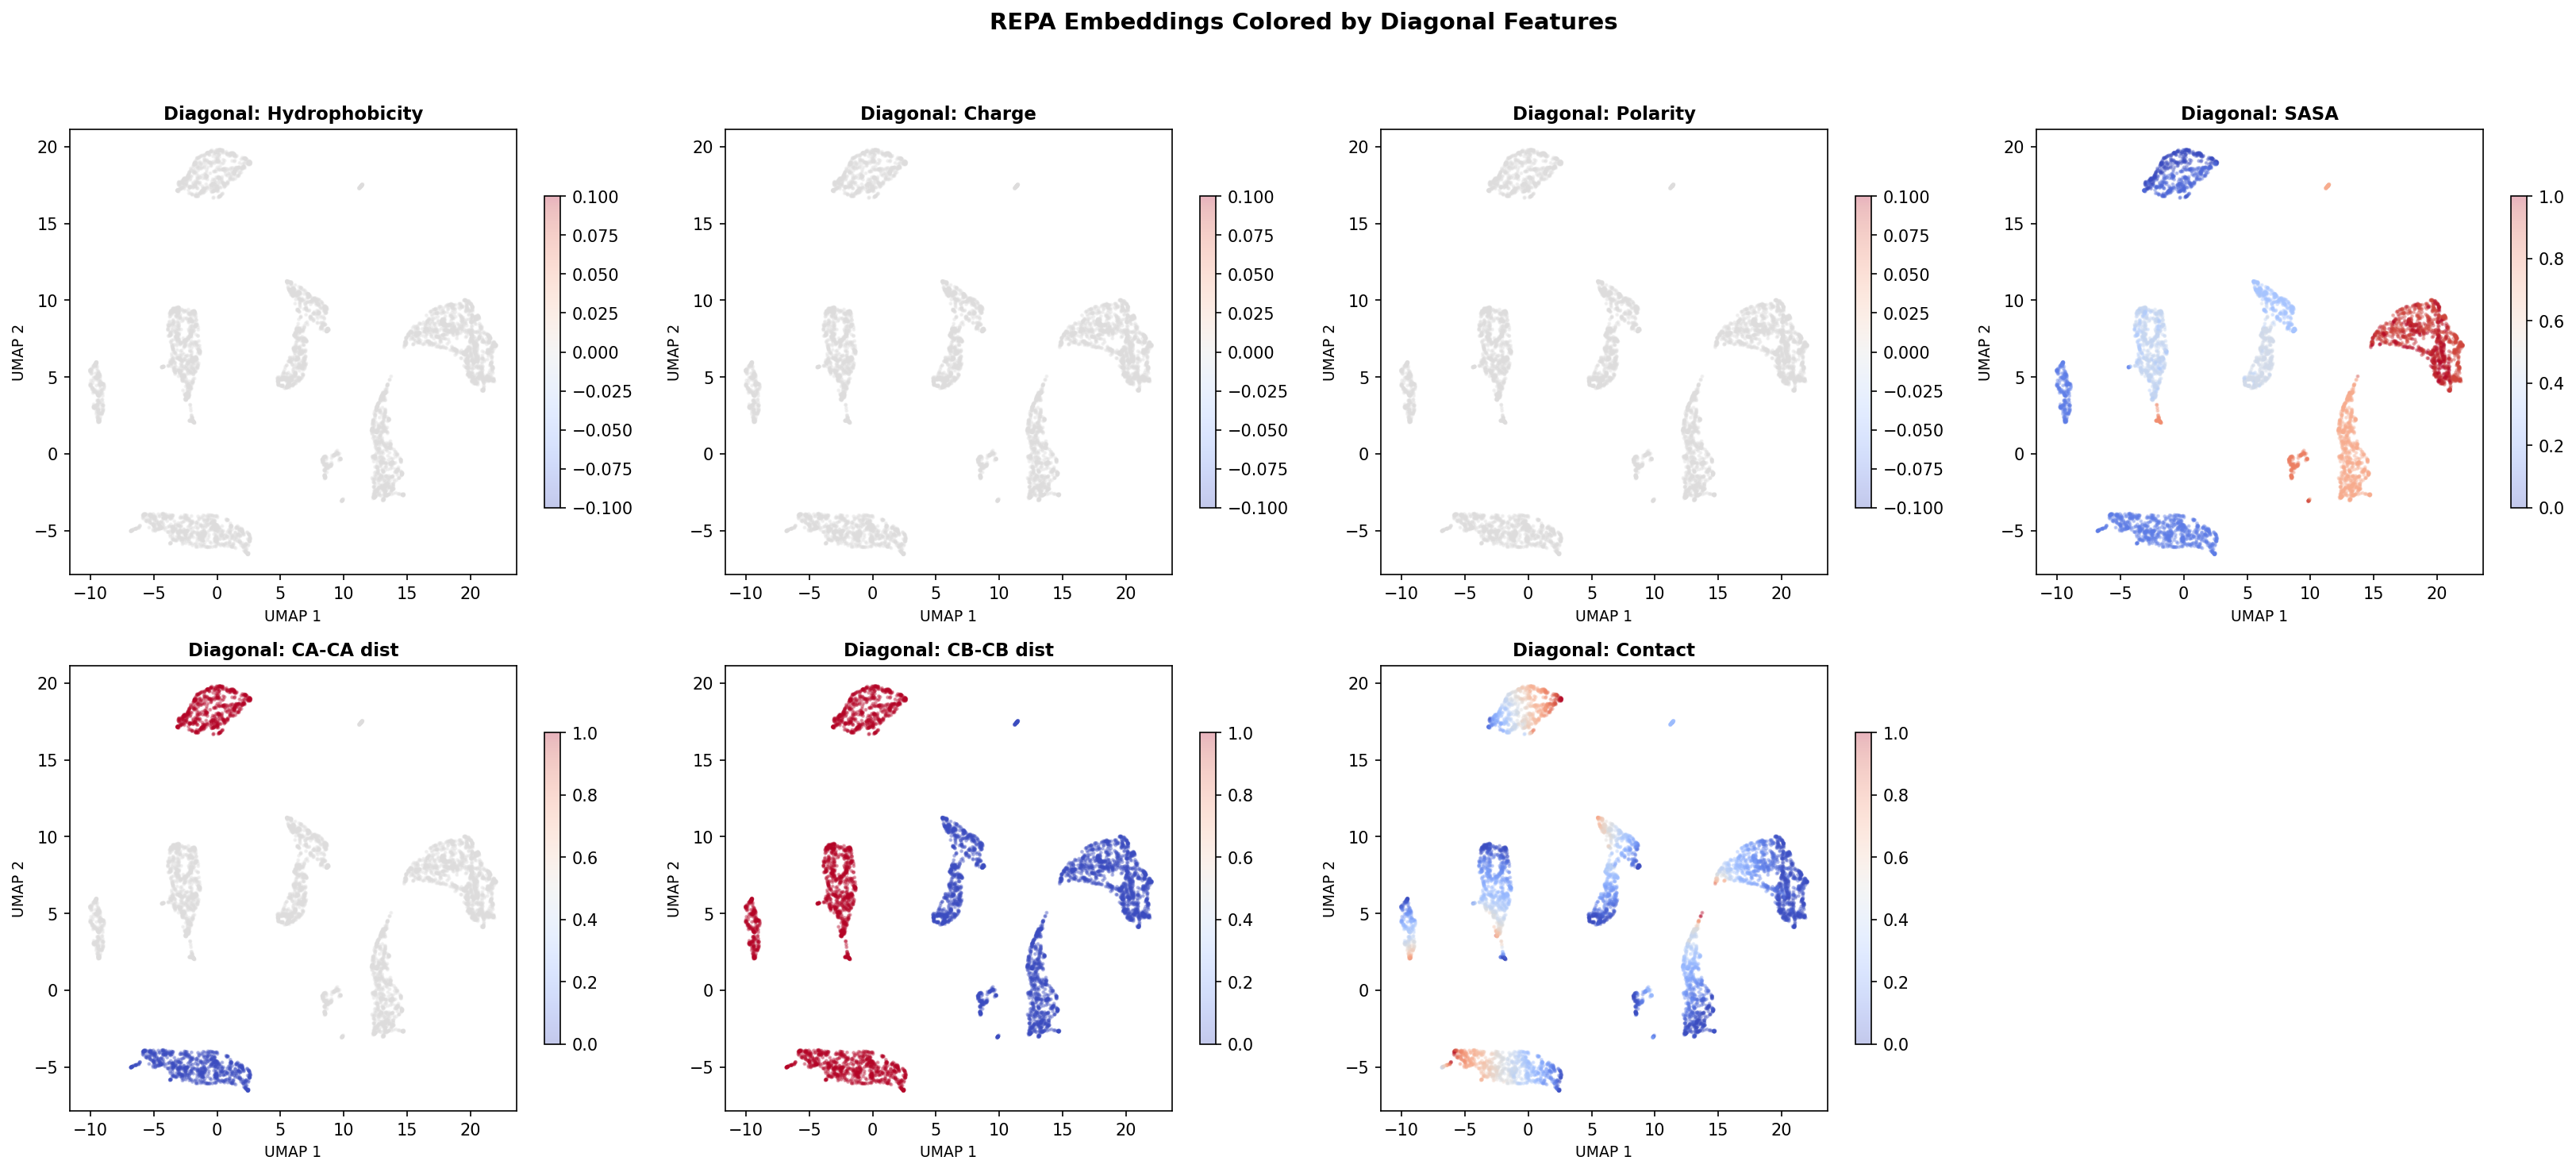

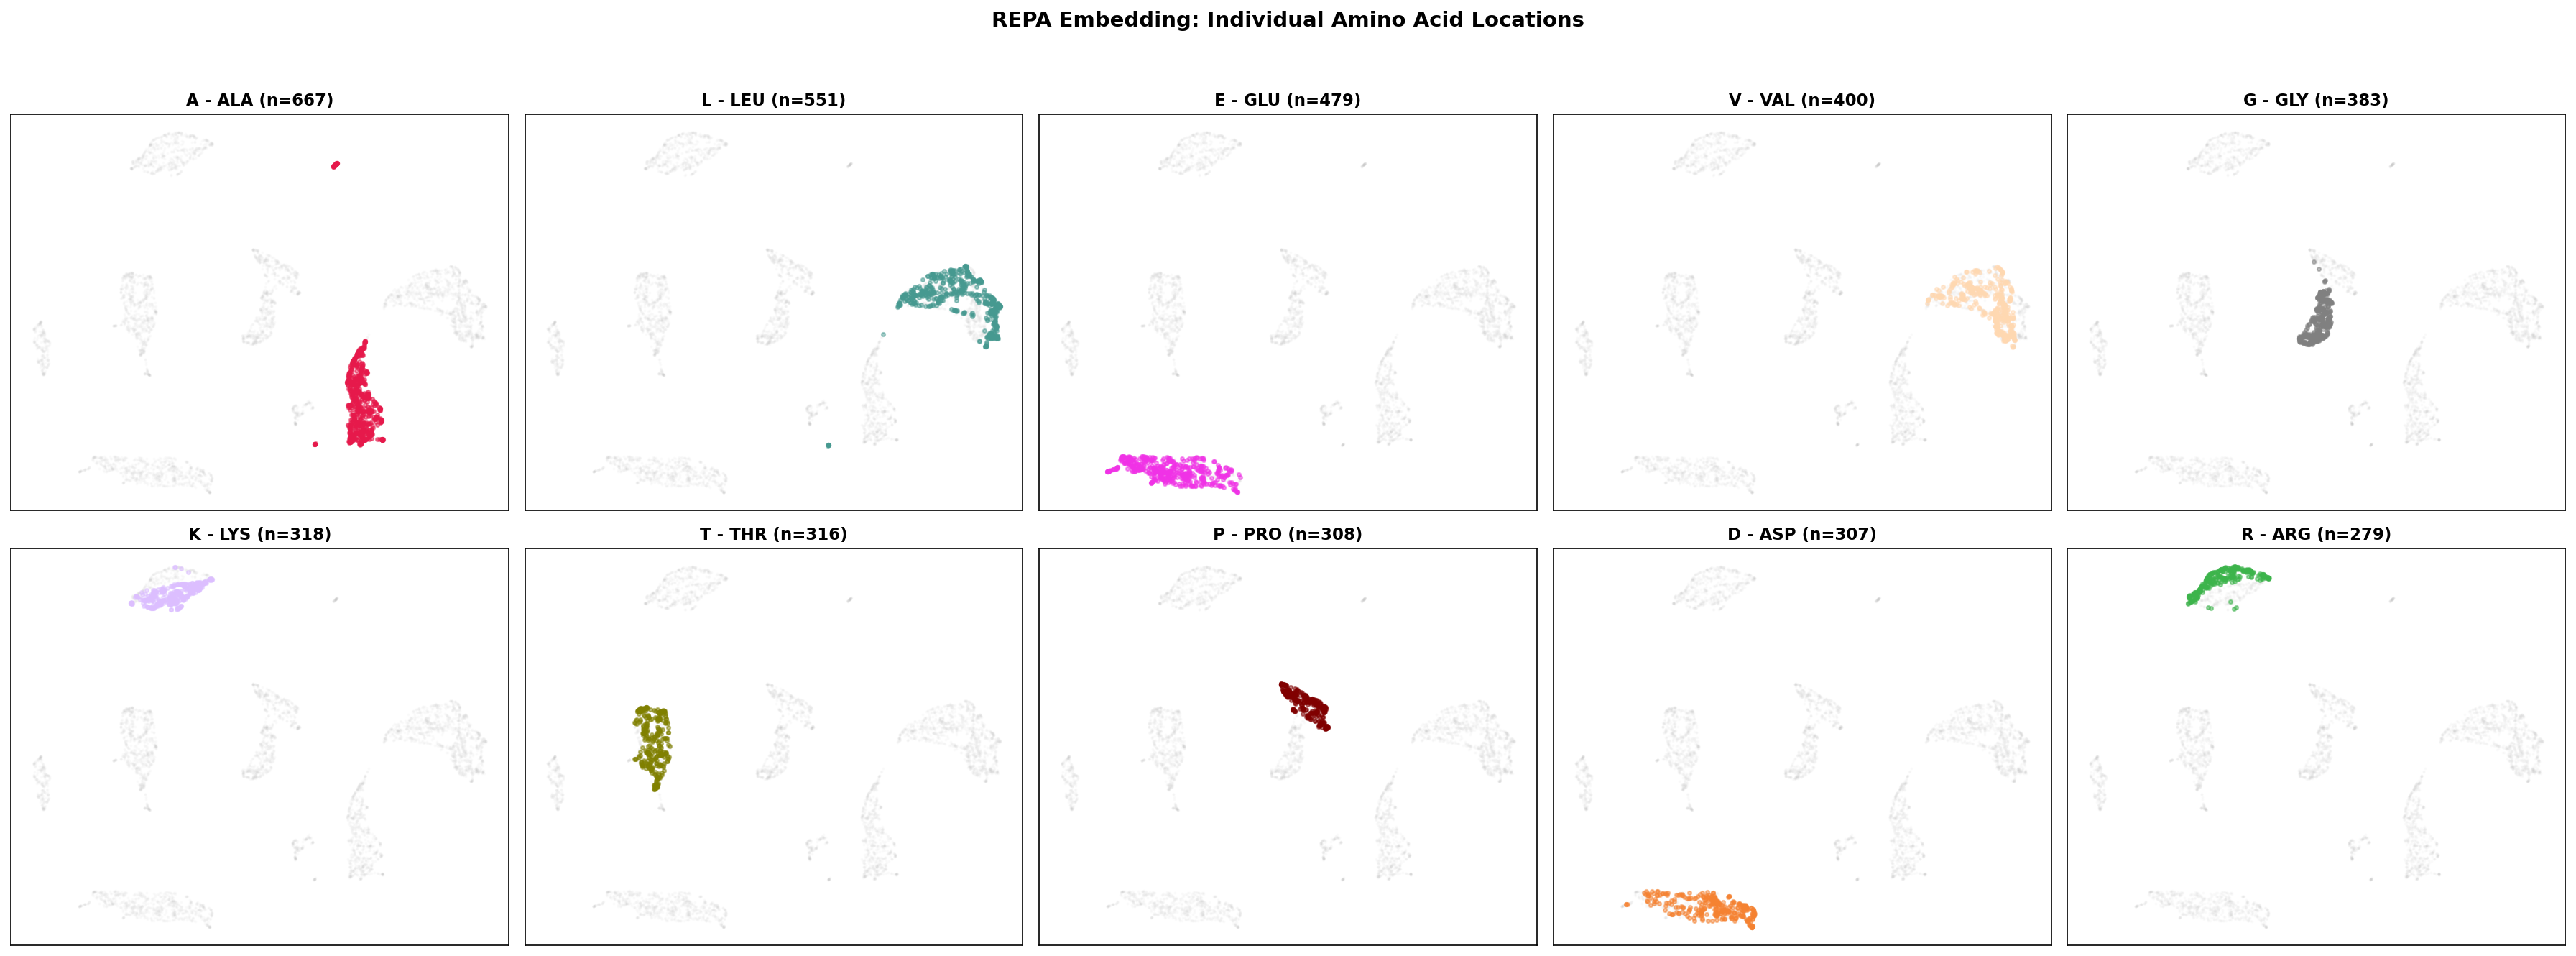

Figures saved to output/vae_eval_notebook/


In [28]:
import umap
from Bio.PDB import PDBParser

# Load pre-extracted pooled REPA features (D=21 per residue)
REPA_DIR = Path("output/vae_repa_features_pooled")
if not REPA_DIR.exists():
    REPA_DIR = Path("../output/vae_repa_features_pooled")

repa_manifest = json.loads((REPA_DIR / "manifest.json").read_text())
print(f"Found {len(repa_manifest)} proteins with REPA features")

# Extract residue identities from the source PDBs
parser = PDBParser(QUIET=True)

all_vecs = []
all_aa = []

for stem, n_res in repa_manifest.items():
    feat = torch.load(REPA_DIR / f"{stem}.pt", weights_only=True).numpy()

    pdb_path = None
    for candidate_dir in [REFERENCE_PDB_DIR, Path("../data"), Path("data")]:
        p = candidate_dir / f"{stem}.pdb"
        if p.exists():
            pdb_path = p
            break
    if pdb_path is None:
        all_vecs.append(feat)
        all_aa.extend(["UNK"] * len(feat))
        continue

    structure = parser.get_structure(stem, str(pdb_path))
    residues = []
    for model in structure:
        for chain in model:
            for res in chain:
                if res.id[0] == " ":
                    residues.append(res.get_resname())
        break

    n = min(len(feat), len(residues))
    all_vecs.append(feat[:n])
    all_aa.extend(residues[:n])

all_vecs = np.concatenate(all_vecs)
print(f"Total residues: {len(all_vecs)}, feature dim: {all_vecs.shape[1]}")

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=42)
emb = reducer.fit_transform(all_vecs)

# One-letter codes
AA_3TO1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
}

# Hand-picked maximally distinct colors for 20 AAs
aa_color_map = {
    'ALA': '#e6194b',  # red
    'ARG': '#3cb44b',  # green
    'ASN': '#4363d8',  # blue
    'ASP': '#f58231',  # orange
    'CYS': '#911eb4',  # purple
    'GLN': '#42d4f4',  # cyan
    'GLU': '#f032e6',  # magenta
    'GLY': '#808080',  # grey
    'HIS': '#bfef45',  # lime
    'ILE': '#fabed4',  # pink
    'LEU': '#469990',  # teal
    'LYS': '#dcbeff',  # lavender
    'MET': '#9a6324',  # brown
    'PHE': '#fffac8',  # beige
    'PRO': '#800000',  # maroon
    'SER': '#aaffc3',  # mint
    'THR': '#808000',  # olive
    'TRP': '#000075',  # navy
    'TYR': '#e6beff',  # light purple
    'VAL': '#ffd8b1',  # apricot
}

# ---------------------------------------------------------------------------
# Plot 1: Single UMAP with all 20 AAs, one color per residue type
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

unique_aa = sorted(set(all_aa) & set(AA_3TO1.keys()))
for aa in unique_aa:
    idx = [i for i, a in enumerate(all_aa) if a == aa]
    ax.scatter(emb[idx, 0], emb[idx, 1], s=6, alpha=0.5,
               c=aa_color_map[aa], label=AA_3TO1[aa],
               edgecolors='none')

ax.set_xlabel('UMAP 1', fontsize=13)
ax.set_ylabel('UMAP 2', fontsize=13)
ax.set_title('VAE REPA Embeddings (D=21) by Amino Acid',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=9, markerscale=3, ncol=2, loc='best',
          title='Residue', title_fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / "umap_repa_all_aa.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Plot 2: UMAP colored by AA biochemical group
# ---------------------------------------------------------------------------
def aa_group(resname):
    if resname in ('ARG', 'LYS'):
        return 'Positive'
    elif resname in ('ASP', 'GLU'):
        return 'Negative'
    elif resname in ('SER', 'THR', 'ASN', 'GLN', 'HIS', 'TYR', 'CYS'):
        return 'Polar uncharged'
    elif resname in ('ALA', 'VAL', 'ILE', 'LEU', 'MET', 'PHE', 'TRP', 'PRO'):
        return 'Hydrophobic'
    elif resname == 'GLY':
        return 'Glycine'
    else:
        return 'Other'

groups = [aa_group(aa) for aa in all_aa]
group_colors = {
    'Hydrophobic': '#e9c46a',
    'Polar uncharged': '#2a9d8f',
    'Positive': '#e76f51',
    'Negative': '#264653',
    'Glycine': '#6a4c93',
    'Other': '#aaaaaa',
}

fig, ax = plt.subplots(figsize=(10, 8))
for grp in ['Hydrophobic', 'Polar uncharged', 'Positive', 'Negative', 'Glycine', 'Other']:
    idx = [i for i, g in enumerate(groups) if g == grp]
    if not idx:
        continue
    ax.scatter(emb[idx, 0], emb[idx, 1], s=5, alpha=0.4,
               c=group_colors[grp], label=grp, edgecolors='none')
ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('VAE REPA Embeddings by AA Group', fontsize=14, fontweight='bold')
ax.legend(markerscale=4, fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / "umap_repa_aa_groups.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Plot 3: UMAP colored by diagonal features (per-residue self-values)
# ---------------------------------------------------------------------------
diag_names = ["Hydrophobicity", "Charge", "Polarity", "SASA",
              "CA-CA dist", "CB-CB dist", "Contact"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for i, (ax, name) in enumerate(zip(axes.flat[:7], diag_names)):
    sc = ax.scatter(emb[:, 0], emb[:, 1], s=2, alpha=0.3,
                    c=all_vecs[:, i], cmap='coolwarm')
    ax.set_title(f'Diagonal: {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('UMAP 1', fontsize=9)
    ax.set_ylabel('UMAP 2', fontsize=9)
    fig.colorbar(sc, ax=ax, shrink=0.7)
axes.flat[7].set_visible(False)

fig.suptitle('REPA Embeddings Colored by Diagonal Features',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "umap_repa_diagonal_features.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Plot 4: Top 10 individual AA types highlighted
# ---------------------------------------------------------------------------
from collections import Counter
aa_counts = Counter(all_aa)
top_aa = [aa for aa, _ in aa_counts.most_common(10) if aa in AA_3TO1]

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
for ax, aa in zip(axes.flat, top_aa):
    is_aa = np.array([a == aa for a in all_aa])
    ax.scatter(emb[~is_aa, 0], emb[~is_aa, 1], s=1, alpha=0.05, c='#cccccc')
    ax.scatter(emb[is_aa, 0], emb[is_aa, 1], s=6, alpha=0.5, c=aa_color_map[aa])
    ax.set_title(f'{AA_3TO1[aa]} - {aa} (n={is_aa.sum()})', fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('REPA Embedding: Individual Amino Acid Locations',
             fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUT_DIR / "umap_repa_individual_aa.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Figures saved to {OUT_DIR}/")